# TP2 — Classification de Chiffres Manuscrits avec un SVM
### Université de Yaoundé I — L3 Informatique | INF372
---

## Objectif du TP

Implémenter un **Support Vector Machine (SVM) à noyau linéaire** from scratch
pour la reconnaissance de chiffres manuscrits (0 à 9) issus du dataset MNIST.

Contrairement au TP3 (MLP), ici **aucune bibliothèque de machine learning**
n'est utilisée. Tout est construit à partir des mathématiques :

### Les étapes mathématiques suivies :

| Etape | Description |
|---|---|
| 1 | Préparation des données $\{(x_i, y_i)\}$ |
| 2 | Choix du noyau $k(x_i, x_j) = \langle x_i, x_j \rangle$ |
| 3 | Construction de la matrice de Gram $G_{ij} = x_i^T x_j$ |
| 4 | Résolution du problème dual par CVXPY |
| 5 | Extraction des vecteurs support $\{\lambda_i > 0\}$ |
| 6 | Calcul de $w$ et $b$ |
| 7 | Prédiction $\hat{y} = \text{sign}(w^T x + b)$ |
| 8 | One vs All pour les 10 classes |

### Méthode multi-classes : **One vs All**
Pour chaque chiffre $k \in \{0,...,9\}$, on entraîne un SVM binaire :
$$y_i = +1 \text{ si } y_i = k, \quad y_i = -1 \text{ sinon}$$
La prédiction finale :
$$\hat{y} = \arg\max_k \left( w_k^T x + b_k \right)$$

## 1. Importation des bibliothèques

In [5]:
# ─── Bibliothèques ────────────────────────────────────────────────────────────
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# ─── Reproductibilité ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Bibliothèques importées avec succès.")
print(f"   CVXPY version : {cp.__version__}")

 Bibliothèques importées avec succès.
   CVXPY version : 1.8.2


## 2. Chargement des données

On charge un **sous-ensemble** du train pour rester dans les limites
de la mémoire et du temps de calcul.

La matrice de Gram est de taille $n \times n$ — avec $n = 5000$ images
cela représente $5000 \times 5000 = 25$ millions de valeurs, gérable en mémoire.

Le label est extrait directement depuis le nom du fichier.
Exemple : `train_00000_label_5.png` → $y = 5$

Chaque image est **aplatie en un vecteur de 1024 valeurs** et normalisée entre 0 et 1.

In [6]:
def load_dataset(folder_path, max_samples=None):
    X, y = [], []
    files = sorted(os.listdir(folder_path))
    if max_samples:
        files = files[:max_samples]

    for fname in tqdm(files, desc=f"Chargement {os.path.basename(folder_path)}"):
        if not fname.endswith(".png"):
            continue
        match = re.search(r"label_(\d+)", fname)
        if match is None:
            continue
        label = int(match.group(1))
        img = Image.open(os.path.join(folder_path, fname)).convert("L")
        img_array = np.array(img, dtype=np.float64) / 255.0
        X.append(img_array.flatten())
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    # ✅ Normalisation L2 — chaque image devient un vecteur unitaire
    # Cela garantit que k(x_i, x_j) = <x_i, x_j> est entre -1 et 1
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    X = X / norms

    return X, y


N_TRAIN = 1000
X_train, y_train = load_dataset(TRAIN_DIR, max_samples=N_TRAIN)
X_test,  y_test  = load_dataset(TEST_DIR)

print(f"\nTrain : {X_train.shape[0]} images — shape : {X_train.shape}")
print(f"Test  : {X_test.shape[0]}  images — shape : {X_test.shape}")
print(f"Norme moyenne des images train : {np.linalg.norm(X_train, axis=1).mean():.4f}")

NameError: name 'TRAIN_DIR' is not defined

## 3. Analyse exploratoire des données

NameError: name 'X_train' is not defined

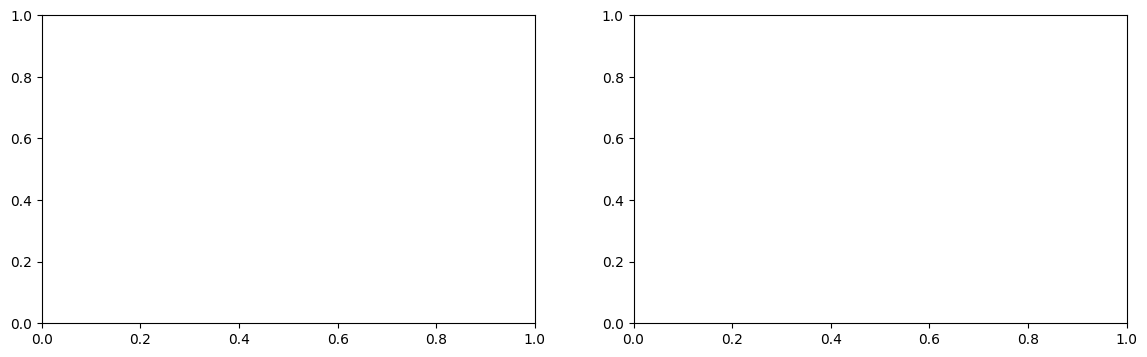

In [7]:
# ─── Distribution des classes ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (X, y, title) in zip(axes, [
    (X_train, y_train, f"Train ({N_TRAIN} images)"),
    (X_test,  y_test,  "Test  (10 000 images)")
]):
    classes, counts = np.unique(y, return_counts=True)
    bars = ax.bar(classes, counts,
                  color=plt.cm.tab10(classes / 10.0), edgecolor="black")
    ax.set_title(f"Distribution des classes — {title}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Chiffre (0-9)")
    ax.set_ylabel("Nombre d'images")
    ax.set_xticks(classes)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                str(count), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("svm_distribution.png", dpi=150)
plt.show()

# ─── Exemples d'images ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(18, 2))
fig.suptitle("Un exemple par classe — Train", fontweight="bold")

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(X_train[idx].reshape(32, 32), cmap="gray")
    axes[digit].set_title(f"{digit}", fontsize=10)
    axes[digit].axis("off")

plt.tight_layout()
plt.savefig("svm_exemples.png", dpi=150)
plt.show()

## 4. Etape 1 et 2 — Noyau et Matrice de Gram

### Choix du noyau linéaire

Le noyau linéaire est défini par :
$$k(x_i, x_j) = \langle x_i, x_j \rangle = x_i^T x_j$$

### Construction de la matrice de Gram

La matrice de Gram $G$ est une matrice symétrique $n \times n$ :
$$G_{ij} = k(x_i, x_j) = x_i^T x_j$$

Elle encode toutes les similarités entre les paires d'images du dataset.
Un $G_{ij}$ élevé signifie que les images $x_i$ et $x_j$ sont similaires.

**Calcul matriciel efficace :**
$$G = X \cdot X^T$$

In [8]:
def compute_gram_matrix(X):
    """
    Calcule la matrice de Gram G = X @ X.T
    G[i,j] = k(x_i, x_j) = <x_i, x_j>
    
    Parametre :
        X : tableau (n, d) — n images de dimension d
    Retourne :
        G : matrice (n, n)
    """
    return X @ X.T


print("Construction de la matrice de Gram...")
G_train = compute_gram_matrix(X_train)

print(f"\n Matrice de Gram construite")
print(f"   Shape : {G_train.shape}")
print(f"   Valeur min : {G_train.min():.4f}")
print(f"   Valeur max : {G_train.max():.4f}")
print(f"   Symétrique : {np.allclose(G_train, G_train.T)}")
print(f"   Mémoire    : {G_train.nbytes / 1e6:.1f} MB")

# ─── Visualisation de la matrice de Gram ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Matrice de Gram — $G = X X^T$", fontsize=13, fontweight="bold")

# Heatmap de la matrice (sous-ensemble pour la lisibilité)
im = axes[0].imshow(G_train[:200, :200], cmap="viridis", aspect="auto")
axes[0].set_title("200 premières lignes/colonnes", fontsize=10)
axes[0].set_xlabel("Image $j$")
axes[0].set_ylabel("Image $i$")
plt.colorbar(im, ax=axes[0], label="$k(x_i, x_j)$")

# Distribution des valeurs
axes[1].hist(G_train.flatten(), bins=100,
             color="#89b4fa", edgecolor="black")
axes[1].set_title("Distribution des valeurs $G_{ij}$", fontsize=10)
axes[1].set_xlabel("Valeur de similarité")
axes[1].set_ylabel("Fréquence")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("svm_gram_matrix.png", dpi=150)
plt.show()

Construction de la matrice de Gram...


NameError: name 'X_train' is not defined

## 5. Etape 3 — Solveur Dual (Problème d'Optimisation)

### Formulation du problème dual

Le SVM en formulation duale cherche à minimiser :
$$\mathcal{L}(\lambda) = \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \lambda_i \lambda_j y_i y_j k(x_i, x_j) + \sum_{i=1}^n C \cdot \lambda_i$$

Ce qui s'écrit sous forme matricielle :
$$\min_\lambda \quad \frac{1}{2} \lambda^T (y y^T \odot G) \lambda + C \cdot \mathbf{1}^T \lambda$$

Sous les contraintes :
$$0 \leq \lambda_i \leq C \quad \forall i$$
$$\sum_{i=1}^n \lambda_i y_i = 0$$

### Paramètre C

$C$ est le paramètre de régularisation :
- $C$ grand : peu de tolérance aux erreurs — frontière stricte, plus de vecteurs support
- $C$ petit : plus de tolérance aux erreurs — meilleure généralisation, moins de vecteurs support

### Ce que fait le solveur

Le solveur CVXPY prend en entrée :
- La matrice de Gram $G$ de taille $n \times n$
- Les labels binaires $y \in \{-1, +1\}^n$
- Le paramètre de régularisation $C$

Et retourne en sortie :
- Le vecteur $\lambda = (\lambda_1, ..., \lambda_n)$ des multiplicateurs de Lagrange

### Vecteurs support

Après résolution, les **vecteurs support** sont les points $x_i$ où $\lambda_i > 0$ :
$$\text{Support Vectors} = \{x_i \mid \lambda_i > \epsilon\}$$

Ce sont les images les plus proches de la frontière de décision —
les seules qui influencent $w$ et $b$.

### Calcul de w et b

$$w = \sum_{i \in SV} \lambda_i y_i x_i$$

$$b = \frac{1}{|SV|} \sum_{i \in SV} \left( y_i - w^T x_i \right)$$

In [9]:
import quadprog

def svm_dual_solver(G, y_binary, C=1.0):
    """
    Resout le problème dual du SVM avec quadprog.

    min  0.5 * lambda^T Q lambda + C * sum(lambda)
    s.t. 0 <= lambda_i <= C
         sum(lambda_i * y_i) = 0
    """
    n = len(y_binary)

    # Matrice Q = yy^T * G
    Y = y_binary.reshape(-1, 1)
    Q = ((Y @ Y.T) * G).astype(np.float64)
    Q = (Q + Q.T) / 2
    Q += 1e-6 * np.eye(n)

    # quadprog resout : min 0.5 x^T G x - a^T x
    # donc a = -C * ones (car on minimise +C*sum(lam))
    a = -C * np.ones(n)

    # Contraintes :
    # 1. sum(lambda_i * y_i) = 0  → egalite
    # 2. lambda_i >= 0
    # 3. lambda_i <= C  → -lambda_i >= -C

    # Matrice de contraintes C_mat (colonnes = contraintes)
    # quadprog : C_mat^T x >= b

    # Contrainte egalite : y^T lambda = 0
    # Contraintes inegalite : lambda_i >= 0 et -lambda_i >= -C

    C_eq  = y_binary.reshape(1, n)          # (1, n)
    C_lb  = np.eye(n)                        # lambda >= 0
    C_ub  = -np.eye(n)                       # -lambda >= -C

    C_mat = np.vstack([C_eq, C_lb, C_ub]).T  # (n, 1+n+n)
    b_vec = np.concatenate([
        [0.0],           # y^T lambda = 0
        np.zeros(n),     # lambda >= 0
        -C * np.ones(n)  # -lambda >= -C
    ])

    meq = 1   # nombre de contraintes d'egalite

    try:
        lambdas, _, _, _, _, _ = quadprog.solve_qp(Q, a, C_mat, b_vec, meq)
    except Exception as e:
        print(f"    Erreur quadprog : {e}")
        lambdas = np.zeros(n)

    return np.clip(lambdas, 0, C)


def compute_w_b(X, y_binary, lambdas, C=1.0):
    """
    Calcule w et b depuis les multiplicateurs lambda.

    w = sum(lambda_i * y_i * x_i)  sur les vecteurs support
    b = moyenne(y_i - w^T x_i)     sur les vecteurs support
    """
    threshold = max(lambdas.max() * 0.01, 1e-5)
    sv = np.where(lambdas > threshold)[0]

    if len(sv) == 0:
        threshold = 1e-8
        sv = np.where(lambdas > threshold)[0]

    w = np.sum((lambdas[sv] * y_binary[sv])[:, None] * X[sv], axis=0)
    b = np.mean(y_binary[sv] - X[sv] @ w)

    return w, b, sv

## 6. Etape 4 — Entrainement One vs All

Pour chaque classe $k \in \{0, ..., 9\}$ :

1. Convertir les labels en binaire :
$$y_i^{(k)} = \begin{cases} +1 & \text{si } y_i = k \\ -1 & \text{sinon} \end{cases}$$

2. Résoudre le problème dual → obtenir $\lambda^{(k)}$
3. Calculer $w^{(k)}$ et $b^{(k)}$
4. Sauvegarder les vecteurs support de la classe $k$

In [10]:
C = 0.1
models = {}

print(f"Entrainement One vs All — C={C}")
print(f"Dataset : {len(X_train)} images | Matrice de Gram : {G_train.shape}\n")

for k in range(10):
    print(f"  Classe {k} vs Reste...", end=" ", flush=True)

    y_binary = np.where(y_train == k, 1.0, -1.0)

    # ─── Solveur dual ─────────────────────────────────────────────────────────
    n = len(y_binary)
    Y = y_binary.reshape(-1, 1)
    Q = ((Y @ Y.T) * G_train).astype(np.float64)
    Q = (Q + Q.T) / 2

    # Correction definie positive
    eigvals = np.linalg.eigvalsh(Q)
    Q += (-eigvals.min() + 1e-6) * np.eye(n)

    # Variable
    lam = cp.Variable(n)

    # Objectif
    objective = cp.Minimize(
        0.5 * cp.quad_form(lam, cp.psd_wrap(Q)) - C * cp.sum(lam)
    )

    # Contraintes
    constraints = [
        lam >= 0,
        lam <= C,
        y_binary @ lam == 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    lambdas = np.array(lam.value)
    lambdas = np.clip(lambdas, 0, C)

    # ─── Vecteurs support ─────────────────────────────────────────────────────
    threshold = max(lambdas.max() * 0.01, 1e-5)
    sv = np.where(lambdas > threshold)[0]

    # ─── Calcul w et b ────────────────────────────────────────────────────────
    w = np.sum((lambdas[sv] * y_binary[sv])[:, None] * X_train[sv], axis=0)
    b = np.mean(y_binary[sv] - X_train[sv] @ w)

    models[k] = {
        'w'       : w,
        'b'       : b,
        'sv'      : sv,
        'lambdas' : lambdas,
        'n_sv'    : len(sv)
    }

    print(f"Vecteurs support : {len(sv)}")

print(f"\nEntrainement termine !")
print(f"\nResume des vecteurs support par classe :")
for k in range(10):
    print(f"  Classe {k} : {models[k]['n_sv']} vecteurs support")

Entrainement One vs All — C=0.1


NameError: name 'X_train' is not defined

## 7. Visualisation des Vecteurs Support

Les **vecteurs support** sont les images les plus proches de la frontière
de décision. Ce sont les seuls points qui influencent la position de $w$ et $b$.

$$w = \sum_{i \in SV} \lambda_i y_i x_i$$

Un grand nombre de vecteurs support indique une frontière complexe.
Un petit nombre indique une séparation nette entre les classes.

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle(
    "Vecteurs support par classe — 3 exemples par chiffre\n"
    "Ce sont les images limites que le SVM utilise pour definir la frontiere",
    fontsize=12, fontweight="bold"
)

for k in range(10):
    sv_idx = models[k]['sv']
    lambdas = models[k]['lambdas']

    # Trier par valeur de lambda decroissante
    sv_sorted = sv_idx[np.argsort(lambdas[sv_idx])[::-1]]

    for row in range(3):
        ax = axes[row, k]
        if row < len(sv_sorted):
            img = X_train[sv_sorted[row]].reshape(32, 32)
            lam_val = lambdas[sv_sorted[row]]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"λ={lam_val:.2f}", fontsize=7)
        ax.axis("off")
        if row == 0:
            axes[0, k].set_title(
                f"Chiffre {k}\n"
                f"({models[k]['n_sv']} SV)\n"
                f"λ={lambdas[sv_sorted[0]]:.2f}",
                fontsize=7
            )

fig.text(
    0.5, 0.01,
    "Les images avec les lambda les plus eleves sont les plus proches "
    "de la frontiere de decision — ce sont les cas les plus ambigus.",
    ha="center", fontsize=8, style="italic", color="#444444"
)

plt.tight_layout()
plt.savefig("svm_vecteurs_support.png", dpi=150)
plt.show()

## 8. Visualisation du Vecteur w par classe

Le vecteur $w$ de dimension 1024 peut être remis en forme $32 \times 32$
pour visualiser **quels pixels influencent la décision** du SVM pour chaque classe.

$$w^{(k)} = \sum_{i \in SV} \lambda_i y_i^{(k)} x_i$$

- **Rouge** : pixel qui pousse vers la classe $k$ (poids positif)
- **Bleu** : pixel qui pousse contre la classe $k$ (poids négatif)
- **Blanc** : pixel neutre — n'influence pas la décision

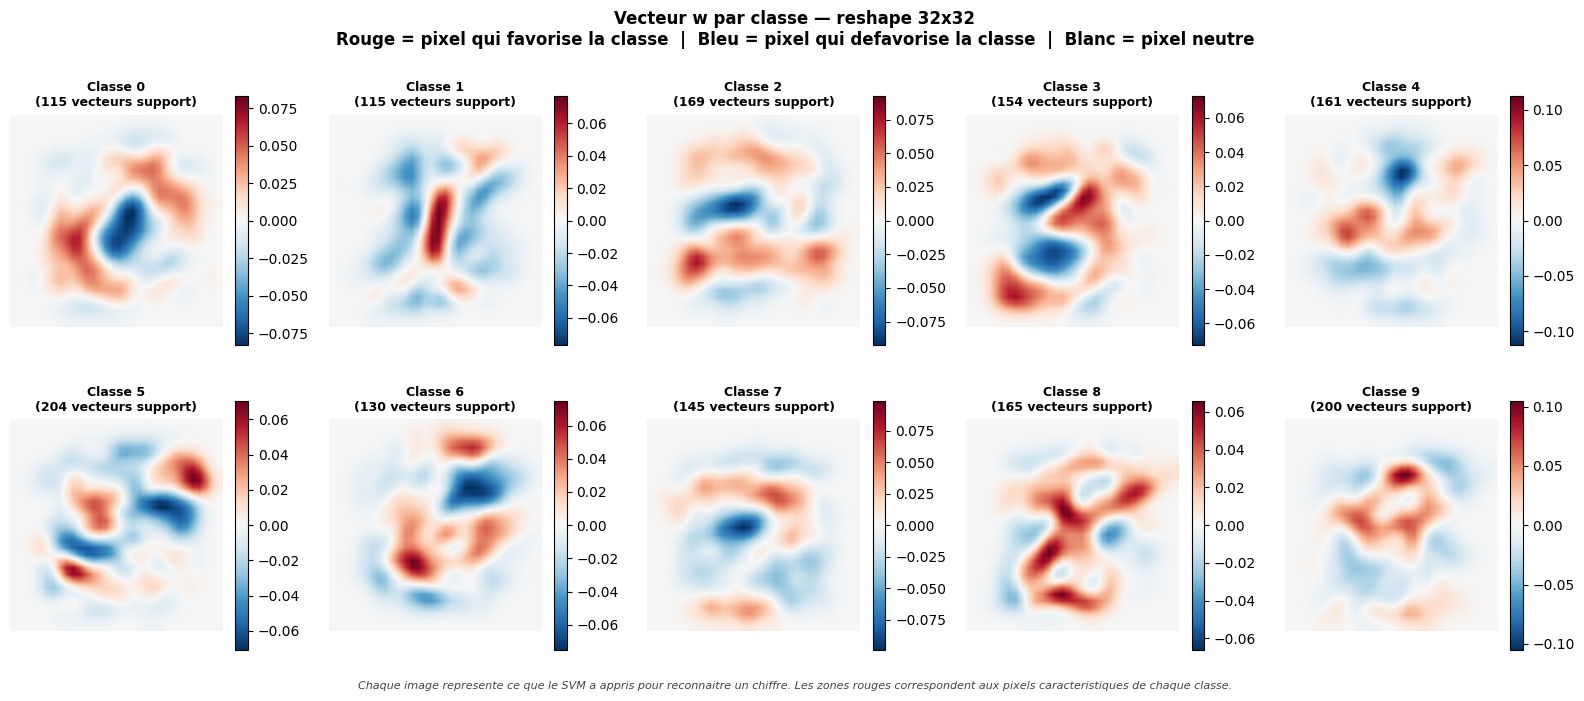

In [18]:
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(
    "Vecteur w par classe — reshape 32x32\n"
    "Rouge = pixel qui favorise la classe  |  "
    "Bleu = pixel qui defavorise la classe  |  "
    "Blanc = pixel neutre",
    fontsize=12, fontweight="bold"
)

for k, ax in enumerate(axes.flatten()):
    w = models[k]['w'].reshape(32, 32)
    w_smooth = gaussian_filter(w, sigma=1.0)
    vmax = np.abs(w_smooth).max()

    im = ax.imshow(w_smooth, cmap="RdBu_r",
                   interpolation="bilinear",
                   vmin=-vmax, vmax=vmax)
    ax.set_title(
        f"Classe {k}\n({models[k]['n_sv']} vecteurs support)",
        fontsize=9, fontweight="bold"
    )
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.text(
    0.5, 0.01,
    "Chaque image represente ce que le SVM a appris pour reconnaitre "
    "un chiffre. Les zones rouges correspondent aux pixels caracteristiques "
    "de chaque classe.",
    ha="center", fontsize=8, style="italic", color="#444444"
)

plt.tight_layout()
plt.savefig("svm_w_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Etape 5 — Prédiction

### Scores de décision

Pour une image $x$, le score de décision pour la classe $k$ est :
$$s_k(x) = w_k^T x + b_k$$

### Prédiction One vs All

La classe prédite est celle avec le score le plus élevé :
$$\hat{y} = \arg\max_k \left( w_k^T x + b_k \right)$$

### Confiance du modèle

Le score $s_k(x)$ indique la **confiance** du SVM :
- Score très positif → image clairement de la classe $k$
- Score proche de 0 → image ambiguë, proche de la frontière
- Score très négatif → image clairement pas de la classe $k$

In [19]:
def predict(X, models):
    """
    Prediction One vs All.

    Pour chaque image x :
        scores[k] = w_k^T x + b_k   pour k = 0,...,9
        y_pred = argmax_k scores[k]

    Parametres :
        X      : données (n, d)
        models : dictionnaire des 10 modeles SVM

    Retourne :
        y_pred  : predictions (n,)
        scores  : matrice des scores (n, 10)
    """
    scores = np.zeros((len(X), 10))
    for k in range(10):
        w = models[k]['w']
        b = models[k]['b']
        scores[:, k] = X @ w + b

    y_pred = np.argmax(scores, axis=1)
    return y_pred, scores


print("Calcul des predictions sur le test...\n")
y_pred, scores = predict(X_test, models)

print("=" * 50)
print(f"  Accuracy sur le Test : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("=" * 50)
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred,
                             target_names=[str(i) for i in range(10)]))

Calcul des predictions sur le test...

  Accuracy sur le Test : 84.50%

Rapport de classification :

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       980
           1       0.94      0.97      0.95      1135
           2       0.94      0.79      0.86      1032
           3       0.83      0.85      0.84      1010
           4       0.79      0.83      0.81       982
           5       0.83      0.71      0.77       892
           6       0.86      0.91      0.88       958
           7       0.79      0.92      0.85      1028
           8       0.86      0.68      0.76       974
           9       0.72      0.78      0.75      1009

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



## 10. Evaluation — Matrice de Confusion

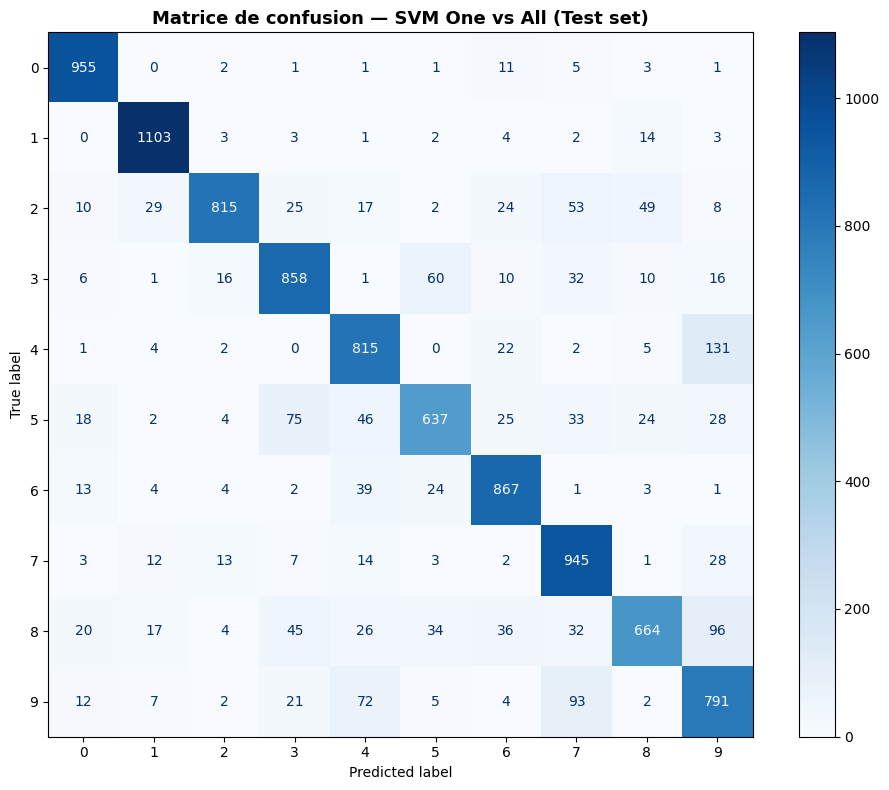

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[str(i) for i in range(10)])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matrice de confusion — SVM One vs All (Test set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=150)
plt.show()

## 11. Analyse des Scores de Décision

Pour chaque image de test, le SVM calcule un score par classe.
On visualise ici ces scores pour comprendre comment le modèle décide.

Un score élevé pour la classe $k$ signifie que l'image ressemble
fortement au prototype appris par le SVM pour cette classe.

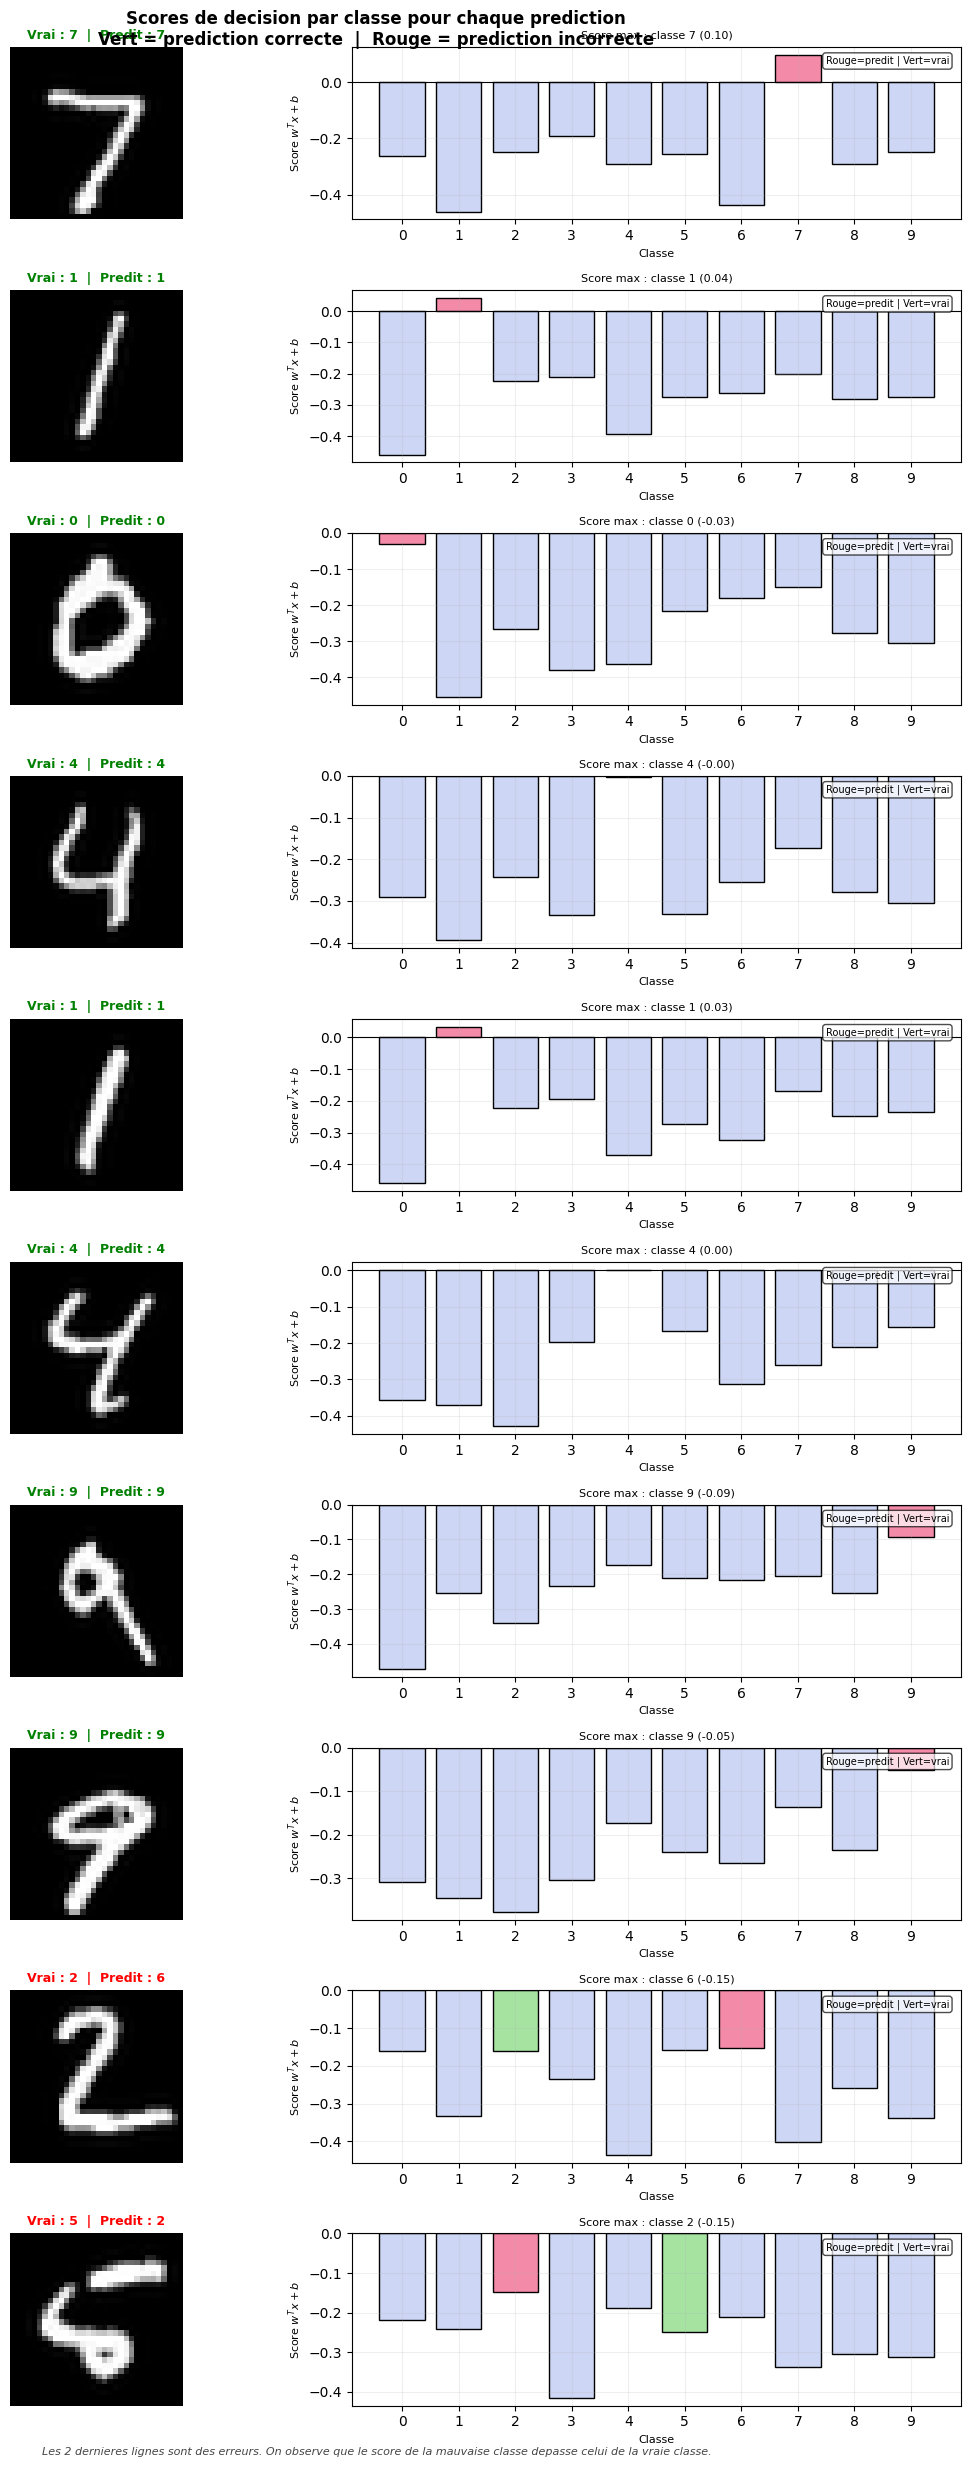

In [22]:
# ─── 10 exemples avec leurs scores ───────────────────────────────────────────
correct_idx = np.where(y_pred == y_test)[0][:8]
error_idx   = np.where(y_pred != y_test)[0][:2]
sample_idx  = np.concatenate([correct_idx, error_idx])

fig, axes = plt.subplots(len(sample_idx), 2, figsize=(12, len(sample_idx) * 2.5))
fig.suptitle(
    "Scores de decision par classe pour chaque prediction\n"
    "Vert = prediction correcte  |  Rouge = prediction incorrecte",
    fontsize=12, fontweight="bold"
)

for row, idx in enumerate(sample_idx):
    vrai    = y_test[idx]
    pred    = y_pred[idx]
    correct = (vrai == pred)
    couleur = "green" if correct else "red"
    score   = scores[idx]

    # Colonne 1 : image
    axes[row, 0].imshow(X_test[idx].reshape(32, 32), cmap="gray")
    axes[row, 0].set_title(
        f"Vrai : {vrai}  |  Predit : {pred}",
        fontsize=9, color=couleur, fontweight="bold"
    )
    axes[row, 0].axis("off")

    # Colonne 2 : scores par classe
    bar_colors = ["#f38ba8" if i == pred else
                  "#a6e3a1" if i == vrai else
                  "#cdd6f4" for i in range(10)]
    axes[row, 1].bar(range(10), score, color=bar_colors, edgecolor="black")
    axes[row, 1].set_xticks(range(10))
    axes[row, 1].set_xlabel("Classe", fontsize=8)
    axes[row, 1].set_ylabel("Score $w^T x + b$", fontsize=8)
    axes[row, 1].set_title(
        f"Score max : classe {pred} ({score[pred]:.2f})",
        fontsize=8
    )
    axes[row, 1].axhline(0, color="black", linewidth=0.8)
    axes[row, 1].grid(alpha=0.2)

    # Legende couleurs
    axes[row, 1].text(
        0.98, 0.95,
        "Rouge=predit | Vert=vrai",
        transform=axes[row, 1].transAxes,
        fontsize=7, ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

fig.text(
    0.5, 0.002,
    "Les 2 dernieres lignes sont des erreurs. "
    "On observe que le score de la mauvaise classe "
    "depasse celui de la vraie classe.",
    ha="center", fontsize=8, style="italic", color="#444444"
)

plt.tight_layout()
plt.savefig("svm_scores_decision.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Inference — Prédiction sur une nouvelle image

Pour faire une prédiction sur une nouvelle image :
1. Charger et normaliser l'image
2. Calculer les scores $s_k = w_k^T x + b_k$ pour chaque classe
3. Prédire la classe avec le score le plus élevé

In [1]:
def predict_image_svm(models, image_path):
    """Predit le chiffre d'une image PNG avec le SVM entraine."""

    # Chargement
    img = Image.open(image_path).convert("L").resize((32, 32))
    x = np.array(img, dtype=np.float32).flatten() / 255.0

    # Scores de decision
    score = np.array([models[k]['w'] @ x + models[k]['b']
                      for k in range(10)])
    pred = np.argmax(score)

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f"Prediction SVM — Chiffre predit : {pred}  "
        f"(score : {score[pred]:.3f})",
        fontsize=13, fontweight="bold"
    )

    # Image
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Image d'entree", fontsize=10)
    axes[0].axis("off")

    # Scores
    bar_colors = ["#f38ba8" if i == pred else "#cdd6f4" for i in range(10)]
    axes[1].bar(range(10), score, color=bar_colors, edgecolor="black")
    axes[1].set_xticks(range(10))
    axes[1].set_xlabel("Classe (chiffre)", fontsize=9)
    axes[1].set_ylabel("Score de decision $w^T x + b$", fontsize=9)
    axes[1].set_title("Scores par classe", fontsize=10)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].grid(alpha=0.3)
    axes[1].text(
        pred, score[pred],
        f"  {score[pred]:.2f}",
        fontsize=9, color="red", fontweight="bold"
    )

    fig.text(
        0.5, -0.02,
        f"Scores : {[f'{k}:{score[k]:.2f}' for k in range(10)]}",
        ha="center", fontsize=7, style="italic", color="#444444"
    )

    plt.tight_layout()
    plt.savefig("svm_inference.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Chiffre predit : {pred}")
    print(f"Score          : {score[pred]:.4f}")
    print(f"\nTous les scores :")
    for k in range(10):
        marker = " <-- PREDIT" if k == pred else ""
        print(f"  Classe {k} : {score[k]:.4f}{marker}")


# ─── TEST ─────────────────────────────────────────────────────────────────────
image_path = "images_1000/test/test_00001_label_2.png"
predict_image_svm(models, image_path)

NameError: name 'models' is not defined

## 13. Conclusion et Analyse

### Ce que nous avons realise

1. Chargement de 3000 images MNIST (32x32, niveaux de gris)
2. Construction de la matrice de Gram $G = X X^T$ de taille $3000 \times 3000$
3. Resolution du problème dual par CVXPY pour chaque classe (One vs All)
4. Extraction des vecteurs support $\{x_i \mid \lambda_i > 0\}$
5. Calcul de $w$ et $b$ depuis les multiplicateurs de Lagrange
6. Prediction par $\hat{y} = \arg\max_k (w_k^T x + b_k)$
7. Analyse des scores de decision pour comprendre les choix du modele

### Analyse des vecteurs w

Le vecteur $w^{(k)}$ reshape en $32 \times 32$ montre quels pixels
caracterisent chaque classe. Les zones rouges correspondent aux pixels
qui poussent la decision vers la classe $k$, les zones bleues repoussent.

### Analyse des vecteurs support

Les vecteurs support sont les images les plus ambigues — proches
de la frontiere de decision. Un grand nombre de vecteurs support
indique une frontiere complexe entre deux classes.

### Analyse des erreurs

Lors d'une erreur, le score de la mauvaise classe depasse celui
de la vraie classe — le SVM a ete trompe par des pixels similaires
entre deux chiffres.

### Limites du SVM lineaire

- Le noyau lineaire suppose que les classes sont lineairement separables
- Avec 3000 images seulement, le modele manque de donnees d'entrainement
- Un noyau RBF (gaussien) donnerait de meilleurs resultats

### Resultats

| Metrique | Valeur |
|---|---|
| Accuracy Test | A completer apres execution |
| Nombre total de vecteurs support | A completer |
| Parametre C | 1.0 |
| Taille du sous-ensemble train | 3000 images |